# Visualize amounts
## Bar plots
### Basic bar plots

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from draft.prepare_internet_adoption_rate import select_adopt

# the top five highest-grossing films for the weekend before Christmas in 2017.

box_office = {
    "Rank": [1, 2, 3, 4, 5],
    "Title": ["Star Wars: The Last Jedi",
              "Jumanji: Welcome to the Jungle",
              "Pitch Perfect 3",
              "The Greatest Showman",
              "Ferdinand"],
    "Weekend Gross": [71565498, 36169328, 19928525, 8805843, 7316746]
}

df = pd.DataFrame(box_office)
df

,Rank,Title,Weekend Gross
0,1,Star Wars: The Last Jedi,71565498
1,2,Jumanji: Welcome to the Jungle,36169328
2,3,Pitch Perfect 3,19928525
3,4,The Greatest Showman,8805843
4,5,Ferdinand,7316746


In [22]:
df['weekend gross (million USD)'] = df['Weekend Gross']/1_000_000
df['Title (short)'] = ['Star Wars','Jumanji','Pitch Perfect','Greatest Showman','Ferdinand']

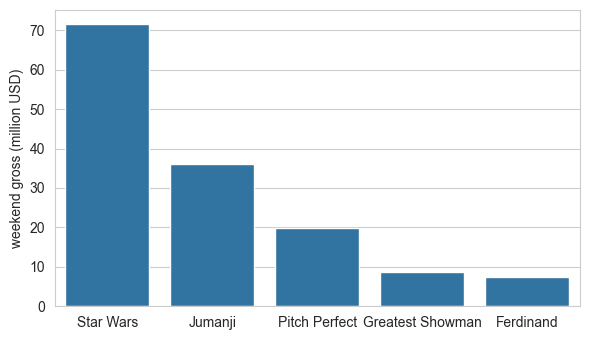

In [33]:
# vertical bars
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

sns.barplot(df, x='Title (short)', y='weekend gross (million USD)', ax=ax)

plt.xlabel("")
plt.show()

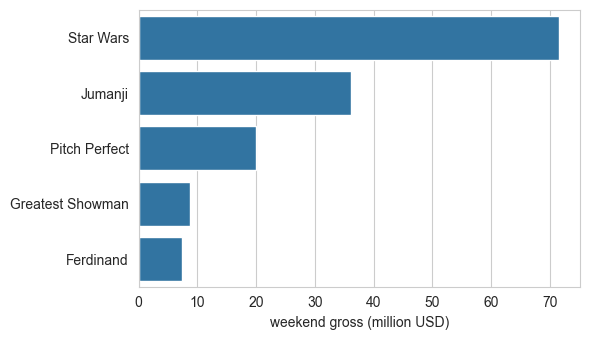

In [4]:
# horizontal bars
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

sns.barplot(df, y='Title (short)', x='weekend gross (million USD)', ax=ax)

plt.ylabel("")
plt.show()

### Grouped bars


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

data = {
    "department": [
        "Electronics", "Clothing", "Home", "Sports",
        "Electronics", "Clothing", "Home", "Sports",
        "Electronics", "Clothing", "Home", "Sports",
        "Electronics", "Clothing", "Home", "Sports",
        "Electronics", "Clothing", "Home", "Sports"
    ],

    "experience level": [
        "Intern", "Intern", "Intern", "Intern",
        "Junior", "Junior", "Junior", "Junior",
        "Mid", "Mid", "Mid", "Mid",
        "Senior", "Senior", "Senior", "Senior",
        "Manager", "Manager", "Manager", "Manager"
    ],

    "monthly sales": [
        12000, 8000, 9500, 7000,
        20000, 15000, 17000, 14000,
        32000, 25000, 28000, 23000,
        45000, 38000, 40000, 36000,
        60000, 52000, 55000, 50000
    ]
}

df = pd.DataFrame(data)

df['experience level'] = df['experience level'].astype(pd.CategoricalDtype(categories=['Intern', 'Junior', 'Mid', 'Senior','Manager'], ordered=True))

print(df.head())

    department experience level  monthly sales
0  Electronics           Intern          12000
1     Clothing           Intern           8000
2         Home           Intern           9500
3       Sports           Intern           7000
4  Electronics           Junior          20000


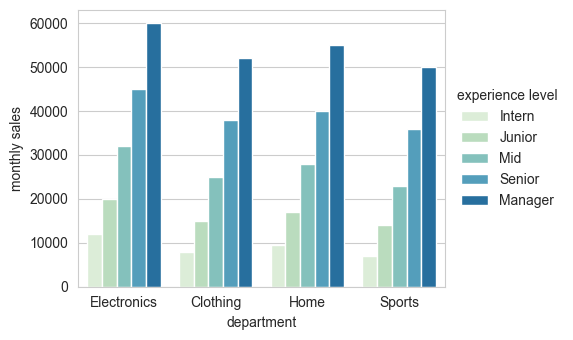

In [6]:
# vertical bars
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

g=sns.barplot(df, x='department', y='monthly sales', hue='experience level',
            palette="GnBu",
            ax=ax)
sns.move_legend(g, loc='center', bbox_to_anchor=(1.17, 0.5), frameon=False)

plt.show()

To avoid the mental efforts of matching bars with color legend, we could also plot four separate figures.

Here we can use `sns.catplot(kind='bar')` instead of `sns.barplot` because the latter does not have `col` parameter.

In [ ]:
g=sns.catplot(df, kind='bar',x='experience level', y='monthly sales',
              col='department',col_wrap=2, height=3,aspect=1.4)

plt.show()

## Dot plots


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

life_expectancy = pd.read_csv("../05-data_cleaning/data/covidtotals.csv", usecols=['iso_code','location','life_expectancy']).nlargest(n=25, columns='life_expectancy')

print(life_expectancy.head())

    iso_code        location  life_expectancy
134      MCO          Monaco            86.75
180      SMR      San Marino            84.97
103      JPN           Japan            84.63
38       CYM  Cayman Islands            83.92
201      CHE     Switzerland            83.78


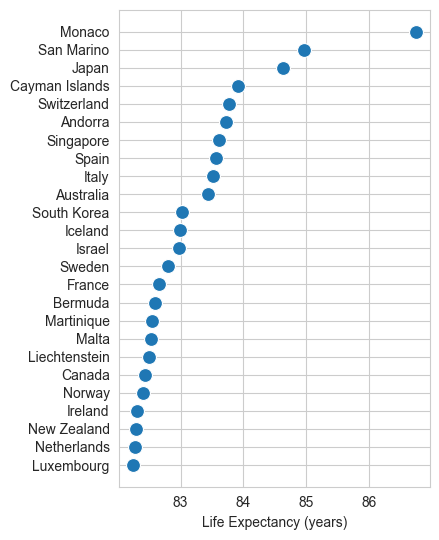

In [12]:
# plot dot plots

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4.5,5.5), tight_layout=True)

sns.scatterplot(data=life_expectancy, x='life_expectancy', y='location', s=100, color="tab:blue", ax=ax)

plt.ylabel("")
plt.xlabel("Life Expectancy (years)")
plt.show()


In [ ]:
%%sql


## Heatmap


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

states = [
    "California", "Texas", "New York", "Florida", "Illinois",
    "Washington", "Arizona", "Colorado", "Oregon", "Nevada",
    "Georgia", "North Carolina", "Michigan", "Ohio", "Virginia",
    "Massachusetts", "Pennsylvania", "Minnesota", "Wisconsin", "Utah"
]

years = list(range(2015, 2026))

data = []

for state in states:
    base = np.random.uniform(5, 25) # Different starting levels
    growth_rate = np.random.uniform(0.8, 3.5) # Different growth speeds

    for i, year in enumerate(years):
        value = base + growth_rate * i + np.random.normal(0, 1.2)
        value = max(0, min(100, value))  # bound between 0–100
        data.append([state, year, round(value, 1)])

df = pd.DataFrame(data, columns=["state", "year", "renewable_energy_share"])

df.head()

,state,year,renewable_energy_share
0,California,2015,13.3
1,California,2016,17.7
2,California,2017,18.9
3,California,2018,22.3
4,California,2019,27.9


In [14]:
# let's format the selected_df to a dataframe for seaborn heatmap generation

plot_df = pd.pivot_table(df, values='renewable_energy_share', index='state', columns='year')
plot_df

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,
Arizona,5.6,6.2,7.8,6.4,9.6,11.4,13.8,12.5,13.3,14.7,17.5
California,13.3,17.7,18.9,22.3,27.9,30.2,32.1,36.7,38.9,42.2,46.5
Colorado,21.5,22.5,24.8,24.1,25.9,27.1,27.1,30.6,31.8,32.8,33.8
Florida,24.6,28.2,30.4,32.9,35.6,37.1,40.9,44.1,48.8,50.8,51.2
Georgia,16.5,19.2,22.3,23.8,24.8,29.0,29.9,34.0,34.5,39.7,39.2
Illinois,7.0,11.5,15.0,17.8,18.7,22.3,26.0,29.8,31.0,34.3,36.2
Massachusetts,24.2,26.4,28.7,33.0,37.7,40.0,41.4,46.2,49.6,51.1,55.5
Michigan,19.8,23.2,25.1,29.5,32.8,34.8,41.1,42.6,43.9,49.3,50.6
Minnesota,25.6,24.7,26.9,28.3,32.1,32.8,36.0,38.3,41.5,46.7,44.3


Text(9.444444444444454, 0.5, '')

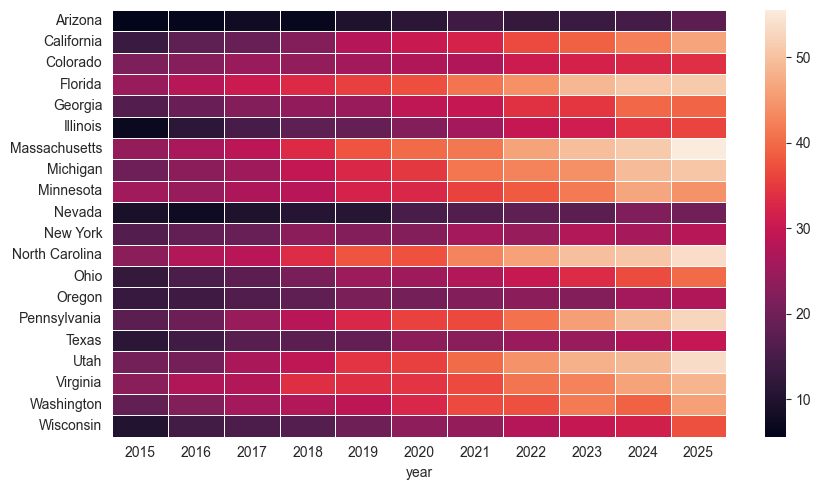

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9,5), tight_layout=True)

# try change the cmap to: rocket_r, mako, flare, magma
g=sns.heatmap(data=plot_df, ax=ax, linewidths=0.5, cmap="rocket")

plt.ylabel("")

Notice that the heatmap above highlights broader trends, but if we need to tell a story about which state has higher renewable energy, then we need to plot the heatmap with order.

Note: more cmap can be found [here](https://seaborn.pydata.org/tutorial/color_palettes.html)

Text(9.444444444444454, 0.5, '')

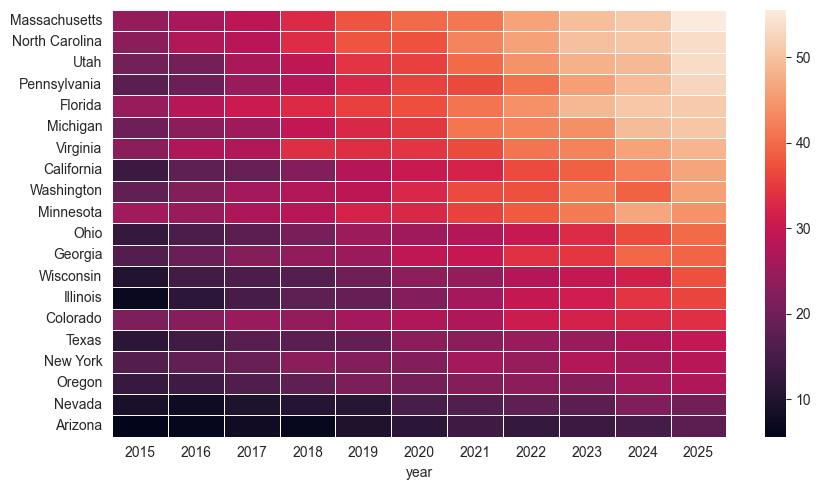

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9,5), tight_layout=True)

# order the data by renewable energy share in 2025
g=sns.heatmap(data=plot_df.sort_values(2025, ascending=False),
              linewidths=0.5, ax=ax)

plt.ylabel("")

### Correlation matrix heatmap

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

covid_totals = pd.read_csv("../05-data_cleaning/data/covidtotals.csv")

covid_totals.head()

,iso_code,lastdate,location,total_cases,total_deaths,total_cases_pm,total_deaths_pm,population,pop_density,median_age,gdp_per_capita,hosp_beds,vac_per_hund,aged_65_older,life_expectancy,hum_dev_ind,region
0,AFG,2024-02-04,Afghanistan,231539.0,7982.0,5629.611,194.073,41128772,54.422,18.6,1803.987,0.50,NaN,2.581,64.83,0.511,South Asia
1,ALB,2024-01-28,Albania,334863.0,3605.0,117813.348,1268.331,2842318,104.871,38.0,11803.431,2.89,NaN,13.188,78.57,0.795,Eastern Europe
2,DZA,2023-12-03,Algeria,272010.0,6881.0,6057.694,153.241,44903228,17.348,29.1,13913.839,1.90,NaN,6.211,76.88,0.748,North Africa
3,ASM,2023-09-17,American Samoa,8359.0,34.0,188712.044,767.581,44295,278.205,NaN,NaN,NaN,NaN,NaN,73.74,NaN,Oceania / Aus
4,AND,2023-05-07,Andorra,48015.0,159.0,601367.684,1991.408,79843,163.755,NaN,NaN,NaN,NaN,NaN,83.73,0.868,Western Europe


In [18]:
# correlation

corr=covid_totals.corr(numeric_only=True)
corr


,total_cases,total_deaths,total_cases_pm,total_deaths_pm,population,pop_density,median_age,gdp_per_capita,hosp_beds,vac_per_hund,aged_65_older,life_expectancy,hum_dev_ind
total_cases,1.000000,0.762998,0.100913,0.146426,0.695625,-0.025125,0.286093,0.192044,0.209188,0.022744,0.289166,0.187538,0.262988
total_deaths,0.762998,1.000000,0.009450,0.274146,0.466781,-0.040507,0.190973,0.125461,0.049745,-0.067747,0.187938,0.113417,0.205922
total_cases_pm,0.100913,0.009450,1.000000,0.440847,-0.132456,0.193272,0.744676,0.661983,0.478298,0.236557,0.720898,0.689163,0.755971
total_deaths_pm,0.146426,0.274146,0.440847,1.000000,-0.071914,0.022683,0.686996,0.289267,0.389162,-0.066557,0.680160,0.490990,0.600523
population,0.695625,0.466781,-0.132456,-0.071914,1.000000,-0.018658,0.025210,-0.049733,-0.043710,-0.108475,-0.008001,-0.036341,-0.018794
pop_density,-0.025125,-0.040507,0.193272,0.022683,-0.018658,1.000000,0.141228,0.294381,0.314577,0.086055,0.065962,0.195529,0.142220
median_age,0.286093,0.190973,0.744676,0.686996,0.025210,0.141228,1.000000,0.650598,0.662467,0.522043,0.915523,0.829922,0.896464
gdp_per_capita,0.192044,0.125461,0.661983,0.289267,-0.049733,0.294381,0.650598,1.000000,0.296186,0.667232,0.510856,0.680024,0.749490
hosp_beds,0.209188,0.049745,0.478298,0.389162,-0.043710,0.314577,0.662467,0.296186,1.000000,-0.077593,0.652752,0.455798,0.565411
vac_per_hund,0.022744,-0.067747,0.236557,-0.066557,-0.108475,0.086055,0.522043,0.667232,-0.077593,1.000000,0.347831,0.670826,0.514868


Text(9.444444444444445, 0.5, '')

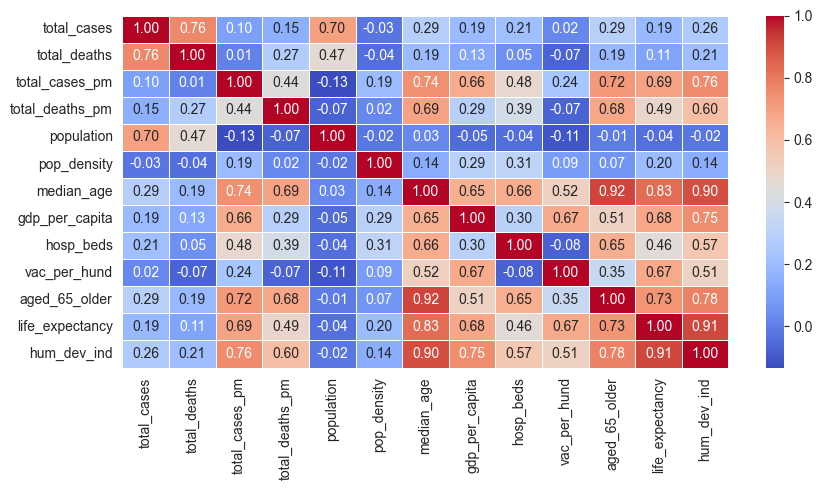

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9,5), tight_layout=True)

g=sns.heatmap(data=corr, linewidths=0.5, annot=True, fmt='.2f', cmap='coolwarm',ax=ax)

plt.ylabel("")